# Brain Log Parser - BGL.log (Memory Optimized)

**Input**: `BGL.log`  
**Output**: `BGL.log_structured.csv`, `BGL.log_templates.csv`, `BGL_parsed.parquet`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

In [2]:
!pip install pyarrow regex psutil -q
print("✅ Done!")

✅ Done!


In [3]:
import pandas as pd
import numpy as np
from scipy import stats

## 2. Upload Files

In [4]:
from google.colab import files

print("📤 Upload Brain.py:")
uploaded = files.upload()
assert 'Brain.py' in uploaded, "⚠️ Cần upload Brain.py!"
print("✅")

📤 Upload Brain.py:


Saving Brain.py to Brain.py
✅


> ⚠️ **Lưu ý**: Upload file lớn (~GB) qua giao diện Colab rất chậm.  
> **Khuyến nghị**: Upload lên Google Drive rồi mount Drive thay thế (xem Cell bên dưới).

In [6]:
log_filename = 'BGL_processed_1500K.log'
log_path = '/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/warmup03/log error classification/data/BGL_1500K_processed.log'  # Sửa đường dẫn phù hợp
total_lines = sum(1 for _ in open(log_path, errors='replace'))
print(f"📝 Tổng dòng: {total_lines:,}")

📝 Tổng dòng: 1,500,000


## 3. Import & RAM Monitor

In [7]:
import pandas as pd
import os, gc, psutil
from datetime import datetime
from Brain import LogParser

def ram_usage(label=''):
    proc = psutil.Process(os.getpid())
    used = proc.memory_info().rss / 1024**2
    avail = psutil.virtual_memory().available / 1024**2
    total = psutil.virtual_memory().total / 1024**2
    tag = f'[{label}] ' if label else ''
    print(f"🧠 {tag}RAM used: {used:.0f} MB | Available: {avail:.0f} / {total:.0f} MB")

ram_usage('start')
print("✅ Imports OK!")

🧠 [start] RAM used: 226 MB | Available: 11632 / 12976 MB
✅ Imports OK!


/content/Brain.py:146: SyntaxWarning: invalid escape sequence '\s'
  splitter = re.sub(" +", "\\\s+", splitters[k])
/content/Brain.py:222: SyntaxWarning: invalid escape sequence '\|'
  s = re.sub("\|", "| ", s)
/content/Brain.py:224: SyntaxWarning: invalid escape sequence '\('
  s = re.sub("\(", "( ", s)
/content/Brain.py:225: SyntaxWarning: invalid escape sequence '\)'
  s = re.sub("\)", ") ", s)
/content/Brain.py:235: SyntaxWarning: invalid escape sequence '\.'
  s = re.sub("\.\.", ".. ", s)
/content/Brain.py:236: SyntaxWarning: invalid escape sequence '\('
  s = re.sub("\(", "( ", s)
/content/Brain.py:237: SyntaxWarning: invalid escape sequence '\)'
  s = re.sub("\)", ") ", s)
/content/Brain.py:242: SyntaxWarning: invalid escape sequence '\('
  s = re.sub("\(", "( ", s)
/content/Brain.py:243: SyntaxWarning: invalid escape sequence '\)'
  s = re.sub("\)", ") ", s)
/content/Brain.py:257: SyntaxWarning: invalid escape sequence '\['
  s = re.sub("\[", "[ ", s)
/content/Brain.py:503: Syn

## 4. Kiểm tra File Log

In [8]:
# Đếm số dòng mà KHÔNG load toàn bộ vào RAM
print("🔍 Counting lines (không load vào RAM)...")
total_lines = 0
with open(log_path, 'r', encoding='utf-8', errors='replace') as f:
    for _ in f:
        total_lines += 1

file_mb = os.path.getsize(log_path) / 1024**2
print(f"📄 File size  : {file_mb:.1f} MB")
print(f"📝 Total lines: {total_lines:,}")

# Preview 5 dòng đầu
print("\n📋 Sample (5 dòng đầu):")
with open(log_path, 'r', encoding='utf-8', errors='replace') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(f"  {i+1}: {line.rstrip()}")

ram_usage('after inspect')

🔍 Counting lines (không load vào RAM)...
📄 File size  : 140.1 MB
📝 Total lines: 1,500,000

📋 Sample (5 dòng đầu):
  1: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 RAS KERNEL INFO instruction cache parity error corrected
  2: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 RAS KERNEL INFO instruction cache parity error corrected
  3: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 RAS KERNEL INFO instruction cache parity error corrected
  4: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.823719 RAS KERNEL INFO instruction cache parity error corrected
  5: 0 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.982731 RAS KERNEL INFO instruction cache parity error corrected
🧠 [after inspect] RAM used: 226 MB | Available: 11589 / 12976 MB


## 5. Cấu hình Brain Parser

> Điều chỉnh `log_format` cho khớp với format thực tế của file BGL.log.

In [9]:
import shutil

# Brain parser cần file nằm trong thư mục indir
indir  = "./log_input/"
outdir = "./Brain_result/"
os.makedirs(indir,  exist_ok=True)
os.makedirs(outdir, exist_ok=True)

# Copy (hoặc symlink) file vào indir nếu chưa ở đó
dest = os.path.join(indir, os.path.basename(log_path))
if not os.path.exists(dest):
    # Dùng symlink để tránh tốn disk gấp đôi
    os.symlink(os.path.abspath(log_path), dest)
    print(f"🔗 Symlinked: {dest}")
else:
    print(f"✅ File đã có trong indir: {dest}")

config = {
    "logname"   : os.path.basename(log_path),        # VD: BGL.log
    "log_format": "<Label> <Node> <Time> <Type> <Component> <Level> <Content>",
    "indir"     : indir,
    "outdir"    : outdir,
    "threshold" : 6,      # Tăng/giảm nếu template quá ít/nhiều
    "delimeter" : [],
    "rex"       : [
        r"core\.\d+",
        r"0x[0-9A-Fa-f]+",
        r"\d+\.\d+\.\d+\.\d+",
        r"(?<=[^A-Za-z0-9])(\-?\+?\d+)(?=[^A-Za-z0-9])|[0-9]+$",
    ]
}

print("⚙️ Config:")
for k, v in config.items():
    if k != 'rex': print(f"  {k:12s}: {v}")

🔗 Symlinked: ./log_input/BGL_1500K_processed.log
⚙️ Config:
  logname     : BGL_1500K_processed.log
  log_format  : <Label> <Node> <Time> <Type> <Component> <Level> <Content>
  indir       : ./log_input/
  outdir      : ./Brain_result/
  threshold   : 6
  delimeter   : []


## 6. Chạy Brain Parser

In [10]:
ram_usage('before parse')
print("\n🚀 Starting Brain parser...")
print("=" * 70)

t0 = datetime.now()

parser = LogParser(
    logname   = config["logname"],
    log_format= config["log_format"],
    indir     = config["indir"],
    outdir    = config["outdir"],
    threshold = config["threshold"],
    delimeter = config["delimeter"],
    rex       = config["rex"]
)
parser.parse(config["logname"])

parsing_time = (datetime.now() - t0).total_seconds()
print(f"\n✅ Parsing done: {parsing_time:.1f}s | {total_lines/parsing_time:,.0f} logs/sec")
ram_usage('after parse')

🧠 [before parse] RAM used: 226 MB | Available: 11590 / 12976 MB

🚀 Starting Brain parser...
Parsing file: ./log_input/BGL_1500K_processed.log
Parsing done...
Time taken   =   0:03:15.701942

✅ Parsing done: 207.5s | 7,228 logs/sec
🧠 [after parse] RAM used: 1426 MB | Available: 10362 / 12976 MB


## 7. Load Kết quả

In [11]:
structured_csv = os.path.join(outdir, config["logname"] + "_structured.csv")
templates_csv  = os.path.join(outdir, config["logname"] + "_templates.csv")

# Chỉ load cột cần thiết + dùng category để tiết kiệm RAM
df_structured = pd.read_csv(
    structured_csv,
    usecols=['EventId', 'EventTemplate'],
    dtype={'EventId': 'category', 'EventTemplate': 'category'}
)
df_templates = pd.read_csv(templates_csv)

print(f"✅ Structured : {len(df_structured):,} rows")
print(f"✅ Templates  : {len(df_templates):,} unique")
print(f"\n📊 Top 10 events:")
print(df_structured['EventId'].value_counts().head(10))
ram_usage('after load results')

✅ Structured : 1,500,000 rows
✅ Templates  : 227 unique

📊 Top 10 events:
EventId
E35     579475
E88     182860
E90     152659
E0       64927
E148     63490
E136     50883
E70      36217
E187     19614
E102     19465
E160     17999
Name: count, dtype: int64
🧠 [after load results] RAM used: 1427 MB | Available: 10363 / 12976 MB


In [12]:
df_structured.head()

,EventId,EventTemplate
0,E0,instruction cache parity error corrected
1,E0,instruction cache parity error corrected
2,E0,instruction cache parity error corrected
3,E0,instruction cache parity error corrected
4,E0,instruction cache parity error corrected


## 8. Merge Kết quả vào Log gốc (Chunk-by-Chunk)

Đọc lại file `.log` theo từng chunk, gắn thêm `EventId` + `EventTemplate`, lưu ra `.parquet`.

In [13]:
import re
import pyarrow as pa
import pyarrow.parquet as pq

In [16]:
# Cấu hình
CHUNK_SIZE     = 100_000
output_parquet = os.path.join(outdir, "BGL_parsed.parquet")

# 1. Chuẩn bị dữ liệu bổ trợ (EventId, EventTemplate)
event_ids       = df_structured['EventId'].astype(str).values
event_templates = df_structured['EventTemplate'].astype(str).values

# 2. Lấy danh sách tên cột từ log_format
col_names = re.findall(r'<(.*?)>', config["log_format"])
print(f"📋 Columns từ log_format: {col_names}")

writer    = None
rows_done = 0

def process_and_write_chunk(buffer_data, current_rows):
    global writer

    # Chuyển buffer thành DataFrame
    chunk = pd.DataFrame(
        [row.split(maxsplit=len(col_names)-1) for row in buffer_data],
        columns=col_names
    )
    n = len(chunk)

    # Gán EventId và EventTemplate
    chunk['EventId']       = event_ids[current_rows : current_rows + n]
    chunk['EventTemplate'] = event_templates[current_rows : current_rows + n]

    # Xử lý Datetime với format đúng: 2005-06-03-15.42.50.363779
    if 'Time' in chunk.columns:
        chunk['Time'] = pd.to_datetime(chunk['Time'], format='%Y-%m-%d-%H.%M.%S.%f', errors='coerce')

    # Ép kiểu string cho các cột khác
    cols_to_fix = ['Label', 'Node', 'Type', 'Component', 'Level', 'EventId', 'EventTemplate']
    for col in cols_to_fix:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype(str)

    # Chuyển đổi sang PyArrow Table
    table = pa.Table.from_pandas(chunk, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(output_parquet, table.schema, compression='snappy')

    writer.write_table(table)
    return n

# 3. Tiến hành đọc file và ghi theo từng Chunk
print(f"\n💾 Merging & saving to: {output_parquet}")

with open(log_path, 'r', encoding='utf-8', errors='replace') as f:
    buffer = []
    for line in f:
        buffer.append(line.rstrip('\n'))

        if len(buffer) >= CHUNK_SIZE:
            num_processed = process_and_write_chunk(buffer, rows_done)
            rows_done += num_processed
            buffer = []
            gc.collect()
            print(f"  💾 Đã xử lý: {rows_done:>9,} dòng", end='\r')

    if buffer:
        num_processed = process_and_write_chunk(buffer, rows_done)
        rows_done += num_processed

if writer:
    writer.close()

size_mb = os.path.getsize(output_parquet) / 1024**2
print(f"\n✅ Hoàn thành! File lưu tại: {output_parquet} ({size_mb:.1f} MB)")

📋 Columns từ log_format: ['Label', 'Node', 'Time', 'Type', 'Component', 'Level', 'Content']

💾 Merging & saving to: ./Brain_result/BGL_parsed.parquet
  💾 Đã xử lý: 1,500,000 dòng
✅ Hoàn thành! File lưu tại: ./Brain_result/BGL_parsed.parquet (19.7 MB)


In [17]:
df_parquet = pd.read_parquet('/content/Brain_result/BGL_parsed.parquet')
df_parquet.head()

,Label,Node,Time,Type,Component,Level,Content,EventId,EventTemplate
0,0,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.363779,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
1,0,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.527847,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
2,0,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.675872,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
3,0,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.823719,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
4,0,R02-M1-N0-C:J12-U11,2005-06-03 15:42:50.982731,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected


## 9. Visualization

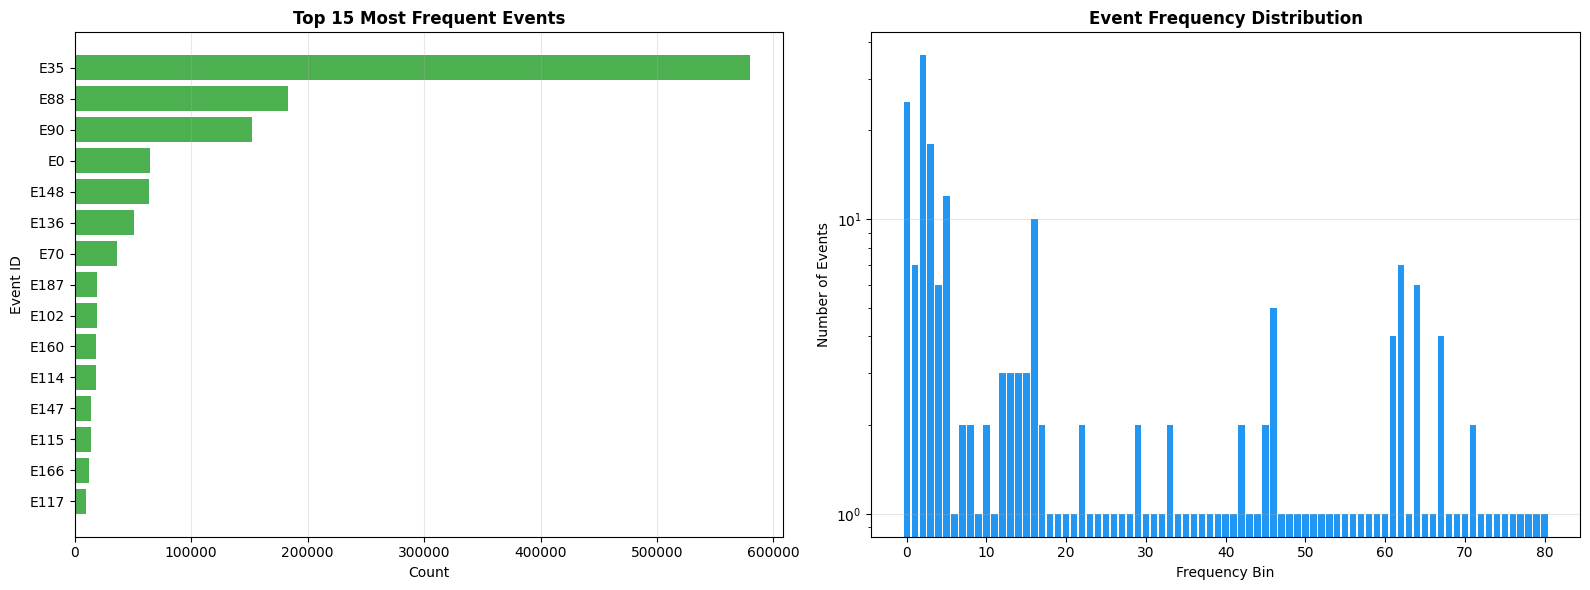

📊 Saved: ./Brain_result/event_distribution.png


In [18]:
import matplotlib.pyplot as plt

event_counts = df_structured['EventId'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15 = event_counts.head(15)
axes[0].barh(range(len(top15)), top15.values, color='#4CAF50')
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15.index)
axes[0].set_xlabel('Count'); axes[0].set_ylabel('Event ID')
axes[0].set_title('Top 15 Most Frequent Events', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

freq_dist = event_counts.value_counts().sort_index()
axes[1].bar(range(len(freq_dist)), freq_dist.values, color='#2196F3')
axes[1].set_xlabel('Frequency Bin'); axes[1].set_ylabel('Number of Events')
axes[1].set_title('Event Frequency Distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
chart_path = os.path.join(outdir, 'event_distribution.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {chart_path}")

## 10. Summary

In [20]:
print("📊 SUMMARY")
print("=" * 60)
print(f"Total log entries : {total_lines:,}")
print(f"Unique templates  : {len(df_templates):,}")
print(f"Compression ratio : {total_lines / len(df_templates):.1f}x")
print(f"Parsing time      : {parsing_time:.1f}s")
print(f"Speed             : {total_lines / parsing_time:,.0f} logs/sec")
print(f"\nOutput files:")
for fn in os.listdir(outdir):
    fp = os.path.join(outdir, fn)
    print(f"  {fn}: {os.path.getsize(fp)/1024**2:.1f} MB")

📊 SUMMARY
Total log entries : 1,500,000
Unique templates  : 227
Compression ratio : 6607.9x
Parsing time      : 207.5s
Speed             : 7,228 logs/sec

Output files:
  BGL_1500K_processed.log_templates.csv: 0.0 MB
  event_distribution.png: 0.1 MB
  BGL_parsed.parquet: 19.7 MB
  BGL_1500K_processed.log_structured.csv: 221.3 MB


In [22]:
df_structured = pd.read_csv('/content/Brain_result/BGL_1500K_processed.log_structured.csv')
df_templates = pd.read_csv('/content/Brain_result/BGL_1500K_processed.log_templates.csv')

df_structured.head()

,LineId,Label,Node,Time,Type,Component,Level,Content,EventId,EventTemplate
0,1,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
1,2,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
2,3,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
3,4,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected
4,5,0,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,RAS,KERNEL,INFO,instruction cache parity error corrected,E0,instruction cache parity error corrected


In [23]:
df_templates.head()

,EventId,EventTemplate,Occurrences
0,E0,"('instruction', 'cache', 'parity', 'error', 'c...",64927
1,E1,"('machine', 'check', 'status', 'register:', '<...",24
2,E2,"('guaranteed', 'instruction', 'cache', 'block'...",2164
3,E3,"('guaranteed', 'data', 'cache', 'block', '<*>')",2164
4,E4,"('rts', 'panic!', '-', 'stopping', 'execution')",2586


## 11. Download

In [21]:
!zip -r brain_results.zip Brain_result/ 2>/dev/null

if os.path.exists('brain_results.zip'):
    zip_mb = os.path.getsize('brain_results.zip') / 1024**2
    print(f"📦 ZIP: {zip_mb:.1f} MB")
    files.download('brain_results.zip')
    print("✅ Download completed!")

  adding: Brain_result/ (stored 0%)
  adding: Brain_result/BGL_1500K_processed.log_templates.csv (deflated 79%)
  adding: Brain_result/event_distribution.png (deflated 25%)
  adding: Brain_result/BGL_parsed.parquet (deflated 27%)
  adding: Brain_result/BGL_1500K_processed.log_structured.csv (deflated 91%)
📦 ZIP: 33.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download completed!
